# Gene Similarity

In [1]:
import sys
sys.path.insert(0, "..")
import re
import seaborn as sns
import pandas as pd
from numpy import exp
from mir.common import GeneLibrary
from mir.distances import GermlineAligner

In [2]:
lib = GeneLibrary.load_default(loci={'TRA', 'TRB'})
print(lib.get_summary())
print(lib.get_loci())

Counter({('human', 'TRA', 'V'): 103, ('human', 'TRB', 'V'): 89, ('human', 'TRA', 'J'): 68, ('human', 'TRB', 'J'): 15, ('human', 'TRB', 'D'): 3})
{'TRA', 'TRB'}


In [3]:
seqs = lib.get_sequences_aa(locus='TRB', gene='V')
print(seqs[0:3])

[('TRBV3-1*02', 'DTAVSQTPKYLVTQMGNDKSIKCEQNLGHDTMYWYKQDSKKFLKIMFSYNNKEIIINETVPNRFSPKSPDKAKLNLHINSLELGDSAVYFCASSQ'), ('TRBV17*01', 'EPGVSQTPRHKVTNMGQEVILRCDPSSGHMFVHWYRQNLRQEMKLLISFQYQNIAVDSGMPKERFTAERPNGTSSTLKIHPAEPRDSAVYLYSSG'), ('TRBV18*01', 'NAGVMQNPRHLVRRRGQEARLRCSPMKGHSHVYWYRQLPEEGLKFMVYLQKENIIDESGMPKERFSAEFPKEGPSILRIQQVVRGDSAAYFCASSP')]


In [4]:
galn = GermlineAligner.from_seqs(seqs)
print(galn.dist)
print(galn.score_norm('TRBV10-1*01', 'TRBV10-1*01'))
print(galn.score_norm('TRBV10-1*01', 'TRBV10-2*01'))

{('TRBV3-1*02', 'TRBV3-1*02'): 503.0, ('TRBV3-1*02', 'TRBV17*01'): 151.0, ('TRBV3-1*02', 'TRBV18*01'): 163.0, ('TRBV3-1*02', 'TRBV16*01'): 168.0, ('TRBV3-1*02', 'TRBV29-1*02'): 84.0, ('TRBV3-1*02', 'TRBV15*03'): 198.0, ('TRBV3-1*02', 'TRBV25-1*01'): 127.0, ('TRBV3-1*02', 'TRBV11-2*02'): 133.0, ('TRBV3-1*02', 'TRBV14*01'): 144.0, ('TRBV3-1*02', 'TRBV23-1*01'): 169.0, ('TRBV3-1*02', 'TRBV12-2*01'): 153.0, ('TRBV3-1*02', 'TRBV10-3*02'): 115.0, ('TRBV3-1*02', 'TRBV15*01'): 196.0, ('TRBV3-1*02', 'TRBV20-1*01'): 76.0, ('TRBV3-1*02', 'TRBV12-5*01'): 190.0, ('TRBV3-1*02', 'TRBV26*01'): 113.0, ('TRBV3-1*02', 'TRBV2*03'): 170.0, ('TRBV3-1*02', 'TRBV12-4*01'): 186.0, ('TRBV3-1*02', 'TRBV10-1*04'): 133.0, ('TRBV3-1*02', 'TRBV24-1*01'): 144.0, ('TRBV3-1*02', 'TRBV11-1*01'): 148.0, ('TRBV3-1*02', 'TRBV15*02'): 196.0, ('TRBV3-1*02', 'TRBV3-1*01'): 477.0, ('TRBV3-1*02', 'TRBV12-1*01'): 123.0, ('TRBV3-1*02', 'TRBV10-2*01'): 144.0, ('TRBV3-1*02', 'TRBV28*01'): 139.0, ('TRBV3-1*02', 'TRBV27*01'): 152.0, 

In [5]:
df = pd.DataFrame([(g1, g2, s, galn.score_norm(g1, g2)) for ((g1, g2), s) in galn.dist.items()],
                  columns=['Segm1', 'Segm2', 'Score', 'Score_norm'])
print(df)

            Segm1        Segm2  Score  Score_norm
0      TRBV3-1*02   TRBV3-1*02  503.0         0.0
1      TRBV3-1*02    TRBV17*01  151.0      -354.0
2      TRBV3-1*02    TRBV18*01  163.0      -348.0
3      TRBV3-1*02    TRBV16*01  168.0      -345.0
4      TRBV3-1*02  TRBV29-1*02   84.0      -419.0
...           ...          ...    ...         ...
7916  TRBV12-3*01   TRBV7-3*02  281.0      -226.0
7917   TRBV5-4*01   TRBV7-3*02  164.0      -341.0
7918  TRBV11-2*03   TRBV7-3*02  279.0      -220.0
7919   TRBV5-1*01   TRBV7-3*02  171.0      -328.0
7920   TRBV4-3*01   TRBV7-3*02  112.0      -394.0

[7921 rows x 4 columns]


In [6]:
df_sfam = pd.DataFrame([(g, re.split('[-\\*]', g)[0]) for (g, s) in seqs],
                       columns=['Segm', 'Fam'])

codes, uniques = pd.factorize(df_sfam['Fam'])
palette = zip(uniques, sns.color_palette(None, len(uniques)).as_hex())
df_sfam = df_sfam.merge(pd.DataFrame(palette, columns=['Fam', 'Col']))
cols = dict(df_sfam[['Segm', 'Col']].itertuples(index=False))

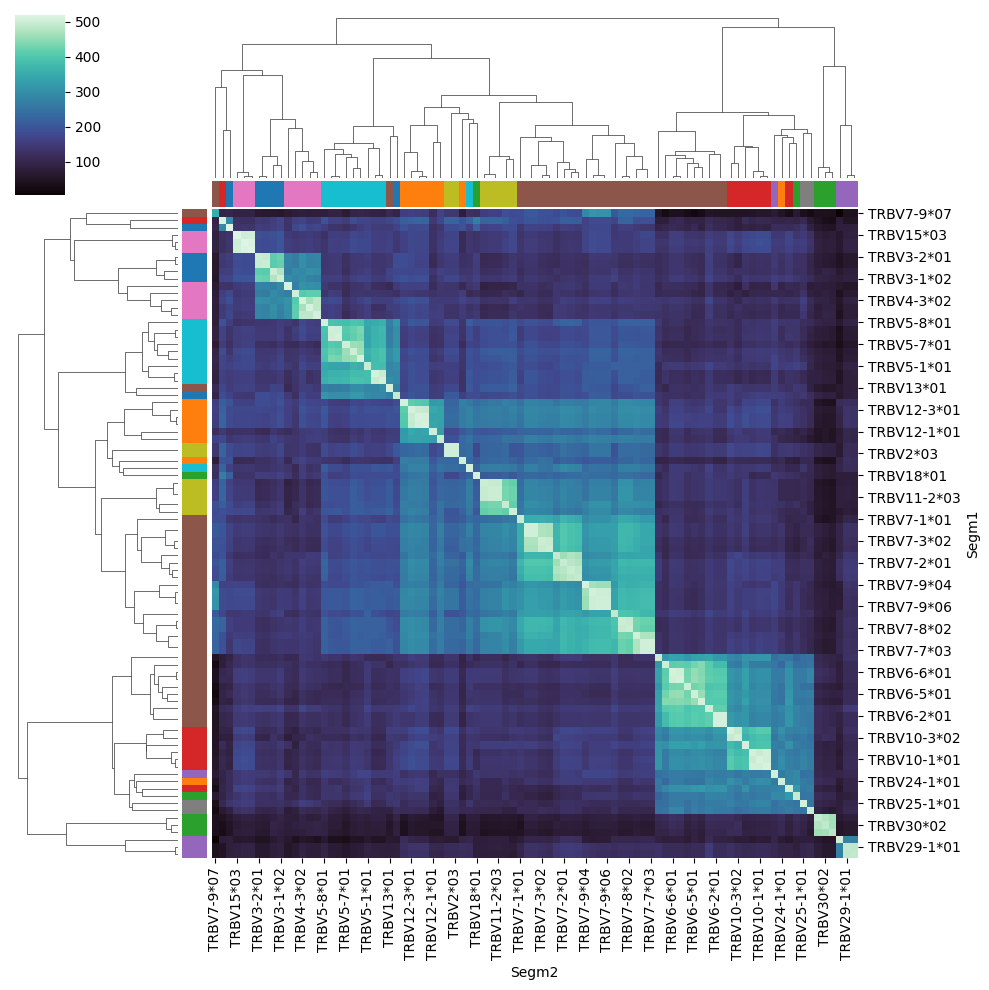

In [7]:
df1 = df.pivot(index='Segm1', columns='Segm2', values='Score')
sns.clustermap(df1, cmap='mako',
               row_colors=df1.index.map(cols),
               col_colors=df1.index.map(cols))

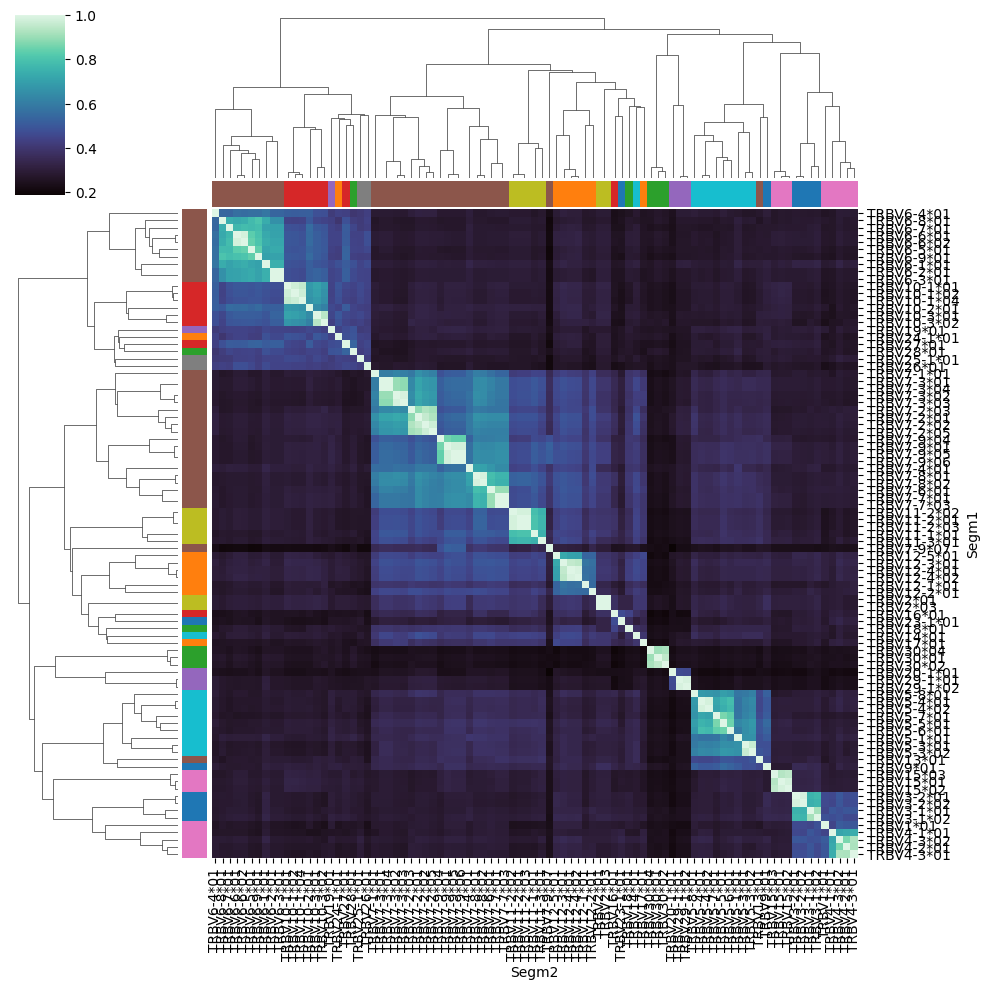

In [8]:
df2 = df.pivot(index='Segm1', columns='Segm2', values='Score_norm')
sns.clustermap(exp(df2/300), cmap='mako',
               row_colors=df2.index.map(cols),
               col_colors=df2.index.map(cols),
               xticklabels=True,
               yticklabels=True)